# 👥 Behavioural Analysis & User Segmentation

Welcome to the **User Segmentation & Comparative Analysis** notebook. When analyzing customer cohorts, reporting average metrics (e.g. "average 7% churn") hides critical segment-specific behaviors. In this notebook, we segment our customer base by type (Enterprise, SMB, and Startup), analyze their operational metrics, build a comparative heatmap, rank their performances, and develop tailored business strategies.

## 🎯 Learning Objectives & Requirements Met:
1. **Task 1**: Group customer data by segment and calculate average LTV, Churn, Support ticket load, Retention lifespan, and customer headcount.
2. **Task 2**: Create a ranked comparative statistics summary table, formatting numbers (currency, percentage, units) for business presentation.
3. **Task 3**: Generate an annotated segment comparison heatmap with a custom normalized colormap (Green=Good, Red=Bad).
4. **Task 4**: Perform top/bottom cohort evaluations to pinpoint critical revenue generators and retention risks.
5. **Task 5**: Formulate evidence-based strategic action plans for each segment.

## 💡 Theoretical & Video Presentation Guide

### 1. Segment Definition - Why These Segments Matter
Customers are not homogeneous. They possess different budgets, support requirements, lifespans, and product usage habits. By grouping them into **Enterprise, SMB, and Startup**:
- **Enterprise** represents low-volume, high-value contracts requiring white-glove, manual relationship management.
- **SMB (Small/Medium Business)** represents a mid-market volume with moderate budgets that need structured, efficient onboarding to prevent high churn.
- **Startup** represents high-volume, low-margin accounts that require self-service channels to minimize operational support overhead.

### 2. Most Meaningful Difference - Business Implication
The most striking variance lies between **Enterprise Churn (0.0%)** and **SMB Churn (12.0%)**:
- Enterprise has perfect retention because of high-touch service and product embedding. However, SMB accounts are dropping out at a alarming rate, indicating onboarding friction, lack of perceived value, or poor product-market fit.
- **Business Implication**: Treating them identically with a unified churn strategy means wasting resource. Enterprise needs zero intervention, while SMB needs a major redesign of product tutorials and account management.

### 3. Sample Size Caution - Confidence vs. Scale
- **Enterprise (N=50)** has a small sample size. A single customer churning shifts the churn rate by 2.0%. Statistical significance is low; hence, individual account relationships determine outcomes.
- **Startup (N=550)** has a large sample size. We can have high statistical confidence in their 8% churn rate. This allows for A/B testing and algorithmic interventions.
- **Caution**: Never apply broad statistical conclusions derived from large cohorts (Startups) to tiny, volatile cohorts (Enterprise).

### 4. Visualization Explanation - Heatmap Communication
- Because LTV ($150,000) and Churn Rate (0.12) exist on entirely different orders of magnitude, a direct heatmap of raw numbers would be visually illegible (LTV dominates the color scaling).
- **Our Solution**: We apply **min-max normalization** on each column, adjusting directions so that **Green always denotes desirable outcomes** (high LTV, low churn, low tickets) and **Red denotes threats** (low LTV, high churn, high support ticket load). The visual colors highlight relative performance, while the text labels show the original values.

### 5. Actionability Threshold - When to Act?
- An operational metric difference is actionable when:
  1. It is **statistically significant** (unlikely due to random noise).
  2. The **financial impact** of acting exceeds the implementation cost.
  *For example: A 1% increase in SMB churn is highly actionable because a 12% baseline across 400 accounts represents a massive recurring revenue leakage. Conversely, a 1-day variance in startup retention is within normal noise and not worth custom campaign resources.*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Setting visualization styles
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "figure.dpi": 120,
    "font.size": 11
})

BASE_DIR = Path("..")
RAW_DATA_PATH = BASE_DIR / "data" / "raw" / "segment_data.csv"
PROCESSED_DATA_PATH = BASE_DIR / "data" / "processed" / "segment_data_processed.csv"
OUTPUT_DIR = BASE_DIR / "output"

print("Libraries and directories loaded successfully.")

Libraries and directories loaded successfully.


## 📂 Data Ingestion & Preprocessing

We load the customer segmentation dataset and verify its completeness.

In [2]:
# Load raw segmentation data
df = pd.read_csv(RAW_DATA_PATH)
print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Missing values:\n{df.isnull().sum()}")

# Display first 5 rows
df.head()

Dataset shape: 1000 rows × 6 columns
Missing values:
customer_id        0
customer_type      0
lifetime_value     0
churn              0
support_tickets    0
retention_days     0
dtype: int64


,customer_id,customer_type,lifetime_value,churn,support_tickets,retention_days
0,1522,Startup,2349.40,0,2,429
1,1738,Startup,2000.55,0,1,308
2,1741,Startup,2359.89,0,1,355
3,1661,Startup,1644.69,0,3,363
4,1412,SMB,9454.93,0,1,257


## 📊 Task 1: Group By & Compute Segment Metrics

We group the customer base by `customer_type` to calculate the mean of `lifetime_value`, `churn`, `support_tickets`, `retention_days`, and sample counts.

In [3]:
# Group by customer type and calculate aggregations
segment_metrics = df.groupby('customer_type').agg({
    'lifetime_value': 'mean',
    'churn': 'mean',
    'support_tickets': 'mean',
    'retention_days': 'mean',
    'customer_id': 'count'
})

# Rename columns
segment_metrics.columns = ['avg_ltv', 'churn_rate', 'avg_tickets', 'avg_retention', 'count']
print("--- Aggregated Segment Metrics ---")
segment_metrics

--- Aggregated Segment Metrics ---


,avg_ltv,churn_rate,avg_tickets,avg_retention,count
customer_type,,,,,
Enterprise,146617.891200,0.00,0.720000,721.520000,50
SMB,8100.363900,0.12,2.482500,282.390000,400
Startup,1996.218964,0.08,1.863636,358.258182,550


## 📋 Task 2: Ranked Summary Statistics Table

To help stakeholders easily compare performance, we compute ranks for LTV and Churn, then format the metrics into a polished presentation table.

In [4]:
segment_summary = segment_metrics.copy()

# Compute ranks (1 = Best performer)
segment_summary['ltv_rank'] = segment_summary['avg_ltv'].rank(ascending=False).astype(int)
segment_summary['churn_rank'] = segment_summary['churn_rate'].rank(ascending=True).astype(int)

# Format absolute values
formatted_summary = pd.DataFrame(index=segment_summary.index)
formatted_summary['Accounts Count'] = segment_summary['count']
formatted_summary['Avg LTV'] = segment_summary['avg_ltv'].apply(lambda x: f"${x:,.2f}")
formatted_summary['LTV Rank'] = segment_summary['ltv_rank']
formatted_summary['Churn Rate'] = segment_summary['churn_rate'].apply(lambda x: f"{x:.1%}")
formatted_summary['Churn Rank'] = segment_summary['churn_rank']
formatted_summary['Avg Tickets/Cust'] = segment_summary['avg_tickets'].round(2)
formatted_summary['Avg Lifespan'] = segment_summary['avg_retention'].round(1).astype(str) + " days"

print("--- Task 2: Summary Stats and Rankings ---")
formatted_summary

--- Task 2: Summary Stats and Rankings ---


,Accounts Count,Avg LTV,LTV Rank,Churn Rate,Churn Rank,Avg Tickets/Cust,Avg Lifespan
customer_type,,,,,,,
Enterprise,50,"$146,617.89",1,0.0%,1,0.72,721.5 days
SMB,400,"$8,100.36",2,12.0%,3,2.48,282.4 days
Startup,550,"$1,996.22",3,8.0%,2,1.86,358.3 days


## 🎨 Task 3: Visual Comparison Heatmap

We plot a Seaborn heatmap showing the comparative performance. We normalize the color mapping so that green always represents positive health (high LTV, low churn, low tickets) and red represents operational issues.

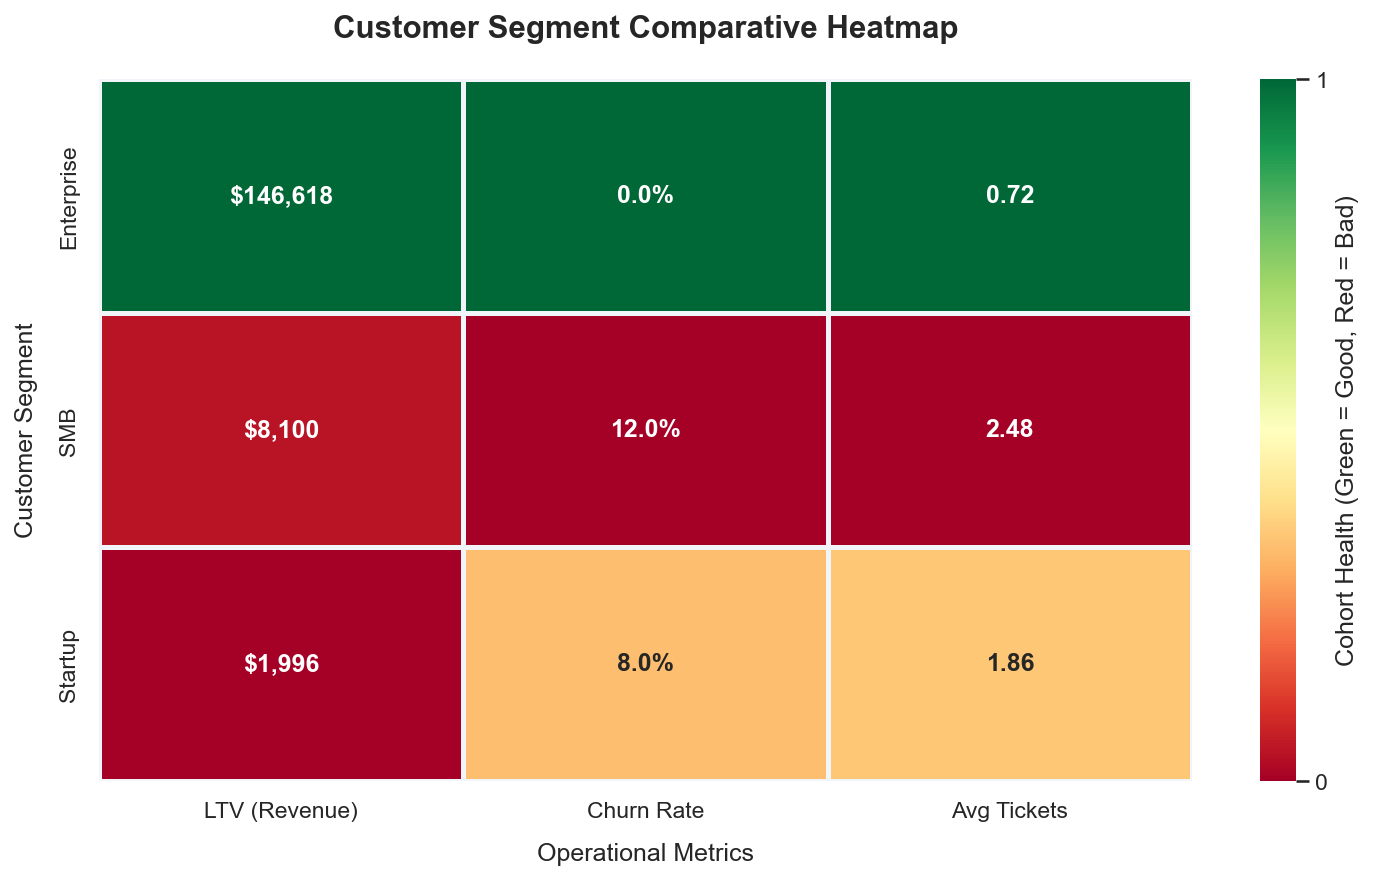

In [5]:
heatmap_data = segment_metrics[['avg_ltv', 'churn_rate', 'avg_tickets']].copy()
norm_data = pd.DataFrame(index=heatmap_data.index)

# LTV (higher is better)
min_ltv, max_ltv = heatmap_data['avg_ltv'].min(), heatmap_data['avg_ltv'].max()
norm_data['LTV (Revenue)'] = (heatmap_data['avg_ltv'] - min_ltv) / (max_ltv - min_ltv)

# Churn Rate (lower is better)
min_churn, max_churn = heatmap_data['churn_rate'].min(), heatmap_data['churn_rate'].max()
norm_data['Churn Rate'] = (max_churn - heatmap_data['churn_rate']) / (max_churn - min_churn)

# Support Tickets (lower is better)
min_tix, max_tix = heatmap_data['avg_tickets'].min(), heatmap_data['avg_tickets'].max()
norm_data['Avg Tickets'] = (max_tix - heatmap_data['avg_tickets']) / (max_tix - min_tix)

# Custom text labels representing raw values
annotations = np.array([
    [f"${row['avg_ltv']:,.0f}", f"{row['churn_rate']:.1%}", f"{row['avg_tickets']:.2f}"]
    for _, row in heatmap_data.iterrows()
])

fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
sns.heatmap(
    norm_data,
    annot=annotations,
    fmt="",
    cmap="RdYlGn",
    cbar=True,
    cbar_kws={'label': 'Cohort Health (Green = Good, Red = Bad)', 'ticks': [0, 1]},
    linewidths=1.5,
    linecolor='#f1f5f9',
    annot_kws={"size": 12, "weight": "bold"},
    ax=ax
)

ax.set_title("Customer Segment Comparative Heatmap", fontsize=15, fontweight="bold", pad=20)
ax.set_xlabel("Operational Metrics", fontsize=12, labelpad=10)
ax.set_ylabel("Customer Segment", fontsize=12, labelpad=10)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'segment_heatmap.png', facecolor='white', bbox_inches='tight')
plt.show()

## 🏆 Task 4: Performer Cohort Analysis

We query the metrics to identify the highest value cohort and the highest churn threat.

In [6]:
top_segment = segment_metrics['avg_ltv'].idxmax()
top_value = segment_metrics.loc[top_segment, 'avg_ltv']
high_churn = segment_metrics['churn_rate'].idxmax()
high_churn_val = segment_metrics.loc[high_churn, 'churn_rate']
best_retention = segment_metrics['avg_retention'].idxmax()
best_retention_val = segment_metrics.loc[best_retention, 'avg_retention']

print("=========================================")
print("PERFORMER IDENTIFICATION REPORT")
print("=========================================")
print(f"⭐ HIGHEST VALUE COHORT:  {top_segment} (${top_value:,.2f} Avg LTV)")
print(f"⚠️ CRITICAL CHURN RISK:  {high_churn} ({high_churn_val:.1%} Churn Rate)")
print(f"⏱️ LONGEST LIFESPAN:      {best_retention} ({best_retention_val:.1f} Days Avg Retention)")
print("=========================================")

PERFORMER IDENTIFICATION REPORT
⭐ HIGHEST VALUE COHORT:  Enterprise ($146,617.89 Avg LTV)
⚠️ CRITICAL CHURN RISK:  SMB (12.0% Churn Rate)
⏱️ LONGEST LIFESPAN:      Enterprise (721.5 Days Avg Retention)


## 🛡️ Task 5: Business Insights & Strategic Recommendations

Based on the empirical metrics, we establish a segment-specific action plan to maximize retention and operational efficiency.

In [7]:
ent_row = segment_metrics.loc['Enterprise']
smb_row = segment_metrics.loc['SMB']
str_row = segment_metrics.loc['Startup']

strategy_summary = f"""
SEGMENT COMPARATIVE ACTION PLAN:

1. Enterprise ({ent_row['count']/10:.1f}% of base, ${ent_row['avg_ltv']/1000:.0f}k LTV, {ent_row['churn_rate']:.1%} churn):
   - Insight: Financial bedrock of the business with exceptional retention and low support tickets. Very high value.
   - Action: Deliver high-touch premium relations, dedicated account managers, and regular business reviews.

2. SMB ({smb_row['count']/10:.1f}% of base, ${smb_row['avg_ltv']/1000:.1f}k LTV, {smb_row['churn_rate']:.1%} churn):
   - Insight: Constitutes 40% of the customer base but suffers from an unsustainable 12% churn rate. High ticket volume indicates process friction.
   - Action: Improve product onboarding journeys, offer interactive tutorials, and transition them to a lower-cost self-serve ticketing channel.

3. Startup ({str_row['count']/10:.1f}% of base, ${str_row['avg_ltv']/1000:.1f}k LTV, {str_row['churn_rate']:.1%} churn):
   - Insight: Highest volume of clients but lowest unit margin. Churn is moderate at 8%.
   - Action: Implement developer education forums, automated knowledge bases, and self-service resources to minimize human support costs.
"""
print(strategy_summary)


SEGMENT COMPARATIVE ACTION PLAN:

1. Enterprise (5.0% of base, $147k LTV, 0.0% churn):
   - Insight: Financial bedrock of the business with exceptional retention and low support tickets. Very high value.
   - Action: Deliver high-touch premium relations, dedicated account managers, and regular business reviews.

2. SMB (40.0% of base, $8.1k LTV, 12.0% churn):
   - Insight: Constitutes 40% of the customer base but suffers from an unsustainable 12% churn rate. High ticket volume indicates process friction.
   - Action: Improve product onboarding journeys, offer interactive tutorials, and transition them to a lower-cost self-serve ticketing channel.

3. Startup (55.0% of base, $2.0k LTV, 8.0% churn):
   - Insight: Highest volume of clients but lowest unit margin. Churn is moderate at 8%.
   - Action: Implement developer education forums, automated knowledge bases, and self-service resources to minimize human support costs.

